# Solutions to Process 3
Investigate the validity of the proposed $\{PPB, \tau_\alpha\}$ system solved for $\{T_e, n_e\}$.

In [1]:
# Reload Process each time (keep editable install up-to-date)
%load_ext autoreload
%autoreload 2
from IPython.display import clear_output
import process
from process.main import SingleRun
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

Running scipy's SLSQP


## Set up
Same as in `solutions_to_process_2.ipynb`.

## f_nd_alpha_electron
$\alpha$ content is currently being kept constant, which may be a shortcoming of this solution definition. What is going on to keep it constant?

Solve Process using the above solution definition for various value of W fraction.

In [ ]:
w_fracs = np.linspace(5e-6, 1e-4, 20)
sol_data = {
    "w": w_fracs,
    "tau_e_scaling_hfact": [],
    "te": [],
    "ne": [],
    "pfus": [],
    "he": [],
    "ploss": [],
    "nd_alphas": [],
    "f_nd_alpha_electron": [],
}
for w_frac in w_fracs:
    # Solve Process each time after modifying W fraction
    single_run = SingleRun("lt_tau_alpha_sol_IN.DAT")
    process.fortran.impurity_radiation_module.impurity_arr_frac[13] = w_frac
    single_run.run()
    sol_data["tau_e_scaling_hfact"].append(
        process.fortran.physics_variables.t_energy_confinement.item()
    )
    sol_data["te"].append(process.fortran.physics_variables.te.item())
    sol_data["ne"].append(process.fortran.physics_variables.dene.item())
    sol_data["pfus"].append(process.fortran.physics_variables.p_fusion_total_mw.item())
    sol_data["he"].append(process.fortran.physics_variables.fusden_plasma_alpha.item())
    sol_data["ploss"].append(process.fortran.physics_variables.p_plasma_loss_mw.item())
    sol_data["nd_alphas"].append(process.fortran.physics_variables.nd_alphas.item())
    sol_data["f_nd_alpha_electron"].append(
        process.fortran.physics_variables.f_nd_alpha_electron.item()
    )

# Clear the lengthy stdout from multiple process runs
clear_output()

Text(0.5, 0.98, 'Various quantities against W density fraction for $\\{PPB, \\tau_\\alpha\\}$ equations solved for $\\{T_e, n_e\\}$')

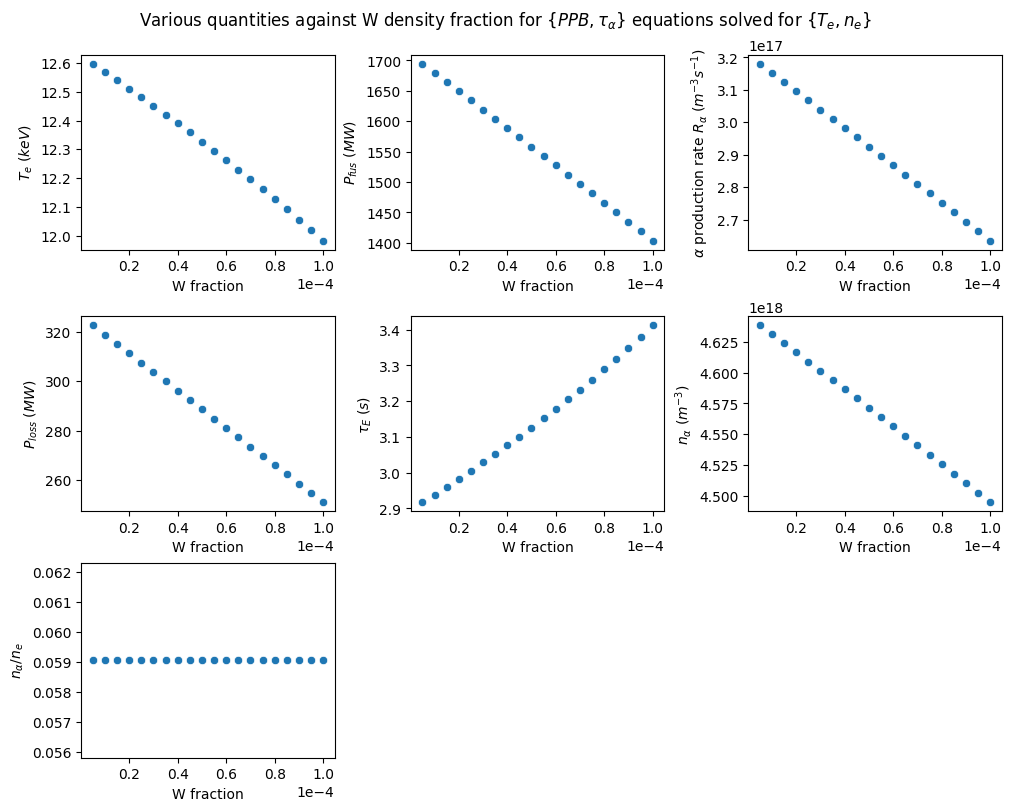

In [ ]:
# Plot
sol_df = pd.DataFrame(sol_data)
fig, ax = plt.subplots(ncols=3, nrows=3, layout="constrained")
fig.set_size_inches(10, 8)

# te plot
ax0 = sns.scatterplot(
    data=sol_df,
    x="w",
    y="te",
    ax=ax[0, 0],
)
ax0.set_xlabel("W fraction")
ax0.set_ylabel(r"$T_e$ $(keV)$")
ax0.ticklabel_format(style="sci", axis="x", scilimits=(0, 0))

# pfus plot
ax1 = sns.scatterplot(
    data=sol_df,
    x="w",
    y="pfus",
    ax=ax[0, 1],
)
ax1.set_xlabel("W fraction")
ax1.set_ylabel(r"$P_{fus}$ $(MW)$")
ax1.ticklabel_format(style="sci", axis="x", scilimits=(0, 0))

# alpha plot
ax2 = sns.scatterplot(
    data=sol_df,
    x="w",
    y="he",
    ax=ax[0, 2],
)
ax2.set_xlabel("W fraction")
ax2.set_ylabel(r"$\alpha$ production rate $R_{\alpha}$ $(m^{-3}s^{-1})$")
ax2.ticklabel_format(style="sci", axis="x", scilimits=(0, 0))

# ploss plot
ax3 = sns.scatterplot(
    data=sol_df,
    x="w",
    y="ploss",
    ax=ax[1, 0],
)
ax3.set_xlabel("W fraction")
ax3.set_ylabel(r"$P_{loss}$ $(MW)$")
ax3.ticklabel_format(style="sci", axis="x", scilimits=(0, 0))

# tau_E plot
ax4 = sns.scatterplot(
    data=sol_df,
    x="w",
    y="tau_e_scaling_hfact",
    ax=ax[1, 1],
)
ax4.set_xlabel("W fraction")
ax4.set_ylabel(r"$\tau_E$ $(s)$")
ax4.ticklabel_format(style="sci", axis="x", scilimits=(0, 0))

# nd_alphas plot
ax5 = sns.scatterplot(
    data=sol_df,
    x="w",
    y="nd_alphas",
    ax=ax[1, 2],
)
ax5.set_xlabel("W fraction")
ax5.set_ylabel(r"$n_{\alpha}$ $(m^{-3})$")
ax5.ticklabel_format(style="sci", axis="x", scilimits=(0, 0))

# f_nd_alpha_electron plot
ax6 = sns.scatterplot(
    data=sol_df,
    x="w",
    y="f_nd_alpha_electron",
    ax=ax[2, 0],
)
ax6.set_xlabel("W fraction")
ax6.set_ylabel(r"$n_{\alpha}/n_{e}$")
ax6.ticklabel_format(style="sci", axis="x", scilimits=(0, 0))

ax[2, 1].axis("off")
ax[2, 2].axis("off")

fig.suptitle(
    r"Various quantities against W density fraction for $\{PPB, \tau_\alpha\}$ equations solved for $\{T_e, n_e\}$"
)

$P_{fus}$ and therefore $R_{\alpha}$ decrease with W fraction. The $\alpha$ density $n_{\alpha}$ decreases too, but the ratio $n_{\alpha}/n_e$ stays constant, as it is currently a fixed input.

## "Unfixing" n_alpha / n_e vary
In the current solution definition, $n_\alpha / n_e$ is a fixed input, and not a solution parameter like in the optimisation problem. This may be calculated as an output, however.

Given
$$ \tau_\alpha = \frac{n_\alpha}{R_{\alpha, V}}$$
where $R_{\alpha, V}$ is the rate of alpha production per volume, and the equation
$$ \frac{\tau_\alpha}{\tau_E} = 5 $$
is now enforced, 
$$ n_\alpha = 5 \tau_E R_{\alpha, V} $$

This has been implemented into `Physics.plasma_composition()` and the results follow.

In [54]:
w_fracs = np.linspace(5e-6, 1e-4, 20)
sol_data = {
    "w": [],
    "tau_e_scaling_hfact": [],
    "te": [],
    "ne": [],
    "pfus": [],
    "he": [],
    "ploss": [],
    "nd_alphas": [],
    "f_nd_alpha_electron": [],
}
for w_frac in w_fracs:
    # Solve Process each time after modifying W fraction
    single_run = SingleRun("lt_tau_alpha_sol_IN.DAT")
    process.fortran.impurity_radiation_module.impurity_arr_frac[13] = w_frac
    try:
        # Handle failed runs
        single_run.run()
    except Exception:
        continue
    sol_data["w"].append(w_frac)
    sol_data["tau_e_scaling_hfact"].append(
        process.fortran.physics_variables.t_energy_confinement.item()
    )
    sol_data["te"].append(process.fortran.physics_variables.te.item())
    sol_data["ne"].append(process.fortran.physics_variables.dene.item())
    sol_data["pfus"].append(process.fortran.physics_variables.p_fusion_total_mw.item())
    sol_data["he"].append(process.fortran.physics_variables.fusden_plasma_alpha.item())
    sol_data["ploss"].append(process.fortran.physics_variables.p_plasma_loss_mw.item())
    sol_data["nd_alphas"].append(process.fortran.physics_variables.nd_alphas.item())
    sol_data["f_nd_alpha_electron"].append(
        process.fortran.physics_variables.f_nd_alpha_electron.item()
    )

# Clear the lengthy stdout from multiple process runs
clear_output()

Text(0.5, 0.98, 'Various quantities against W density fraction for $\\{PPB, \\tau_\\alpha\\}$ equations solved for $\\{T_e, n_e\\}$')

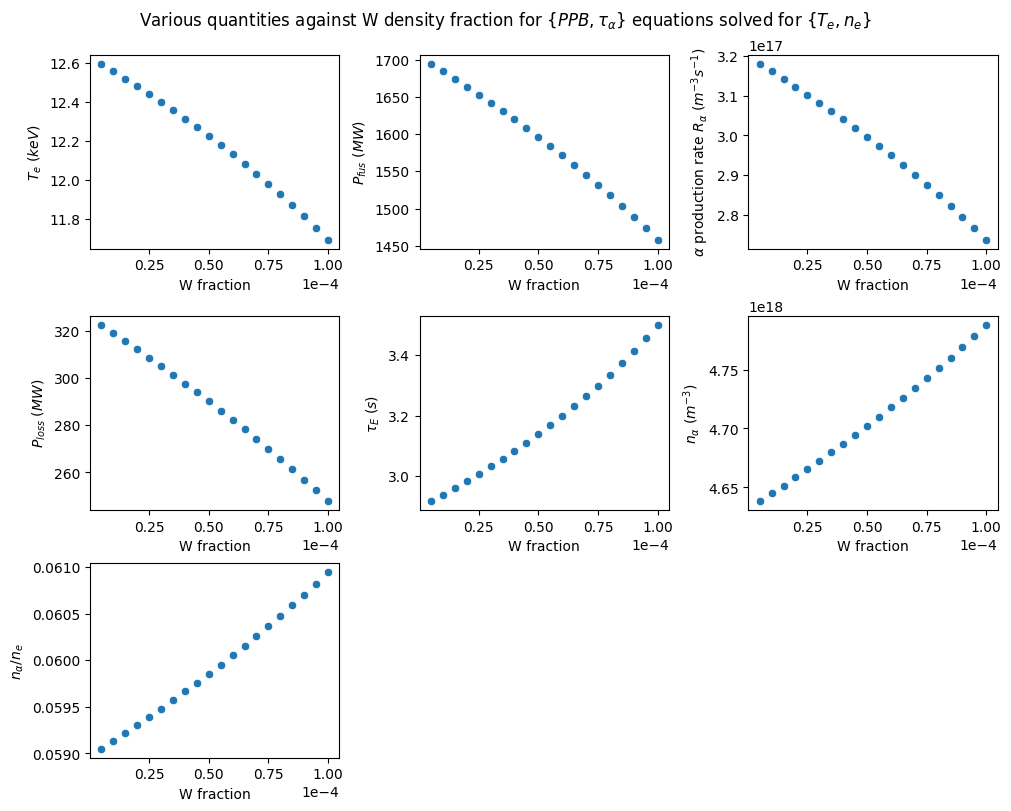

In [55]:
# Plot
sol_df = pd.DataFrame(sol_data)
fig, ax = plt.subplots(ncols=3, nrows=3, layout="constrained")
fig.set_size_inches(10, 8)

# te plot
ax0 = sns.scatterplot(
    data=sol_df,
    x="w",
    y="te",
    ax=ax[0, 0],
)
ax0.set_xlabel("W fraction")
ax0.set_ylabel(r"$T_e$ $(keV)$")
ax0.ticklabel_format(style="sci", axis="x", scilimits=(0, 0))

# pfus plot
ax1 = sns.scatterplot(
    data=sol_df,
    x="w",
    y="pfus",
    ax=ax[0, 1],
)
ax1.set_xlabel("W fraction")
ax1.set_ylabel(r"$P_{fus}$ $(MW)$")
ax1.ticklabel_format(style="sci", axis="x", scilimits=(0, 0))

# alpha plot
ax2 = sns.scatterplot(
    data=sol_df,
    x="w",
    y="he",
    ax=ax[0, 2],
)
ax2.set_xlabel("W fraction")
ax2.set_ylabel(r"$\alpha$ production rate $R_{\alpha}$ $(m^{-3}s^{-1})$")
ax2.ticklabel_format(style="sci", axis="x", scilimits=(0, 0))

# ploss plot
ax3 = sns.scatterplot(
    data=sol_df,
    x="w",
    y="ploss",
    ax=ax[1, 0],
)
ax3.set_xlabel("W fraction")
ax3.set_ylabel(r"$P_{loss}$ $(MW)$")
ax3.ticklabel_format(style="sci", axis="x", scilimits=(0, 0))

# tau_E plot
ax4 = sns.scatterplot(
    data=sol_df,
    x="w",
    y="tau_e_scaling_hfact",
    ax=ax[1, 1],
)
ax4.set_xlabel("W fraction")
ax4.set_ylabel(r"$\tau_E$ $(s)$")
ax4.ticklabel_format(style="sci", axis="x", scilimits=(0, 0))

# nd_alphas plot
ax5 = sns.scatterplot(
    data=sol_df,
    x="w",
    y="nd_alphas",
    ax=ax[1, 2],
)
ax5.set_xlabel("W fraction")
ax5.set_ylabel(r"$n_{\alpha}$ $(m^{-3})$")
ax5.ticklabel_format(style="sci", axis="x", scilimits=(0, 0))

# f_nd_alpha_electron plot
ax6 = sns.scatterplot(
    data=sol_df,
    x="w",
    y="f_nd_alpha_electron",
    ax=ax[2, 0],
)
ax6.set_xlabel("W fraction")
ax6.set_ylabel(r"$n_{\alpha}/n_{e}$")
ax6.ticklabel_format(style="sci", axis="x", scilimits=(0, 0))

ax[2, 1].axis("off")
ax[2, 2].axis("off")

fig.suptitle(
    r"Various quantities against W density fraction for $\{PPB, \tau_\alpha\}$ equations solved for $\{T_e, n_e\}$"
)

n_alpha / n_e is now increasing with W fraction, instead of being constant: the increase in tau_E dominates the decrease in R_alpha. This quantity is now no longer fixed.

## Model problems at high W values
Does n_alpha / n_E turn over at high enough W?

In [ ]:
w_fracs = np.linspace(1.65e-4, 1.8e-4, 30)
# w_fracs = np.array([1.9e-4])  # 1.9e-4 fails
sol_data = {
    "w": [],
    "tau_e_scaling_hfact": [],
    "te": [],
    "ne": [],
    "pfus": [],
    "he": [],
    "ploss": [],
    "nd_alphas": [],
    "f_nd_alpha_electron": [],
}
for w_frac in w_fracs:
    # Solve Process each time after modifying W fraction
    single_run = SingleRun("lt_tau_alpha_sol_IN.DAT")
    process.fortran.impurity_radiation_module.impurity_arr_frac[13] = w_frac
    try:
        # Handle failed runs
        single_run.run()
    except Exception:
        continue
    sol_data["w"].append(w_frac)
    sol_data["tau_e_scaling_hfact"].append(
        process.fortran.physics_variables.t_energy_confinement.item()
    )
    sol_data["te"].append(process.fortran.physics_variables.te.item())
    sol_data["ne"].append(process.fortran.physics_variables.dene.item())
    sol_data["pfus"].append(process.fortran.physics_variables.p_fusion_total_mw.item())
    sol_data["he"].append(process.fortran.physics_variables.fusden_plasma_alpha.item())
    sol_data["ploss"].append(process.fortran.physics_variables.p_plasma_loss_mw.item())
    sol_data["nd_alphas"].append(process.fortran.physics_variables.nd_alphas.item())
    sol_data["f_nd_alpha_electron"].append(
        process.fortran.physics_variables.f_nd_alpha_electron.item()
    )

# Clear the lengthy stdout from multiple process runs
clear_output()

Text(0.5, 0.98, 'Various quantities against W density fraction for $\\{PPB, \\tau_\\alpha\\}$ equations solved for $\\{T_e, n_e\\}$')

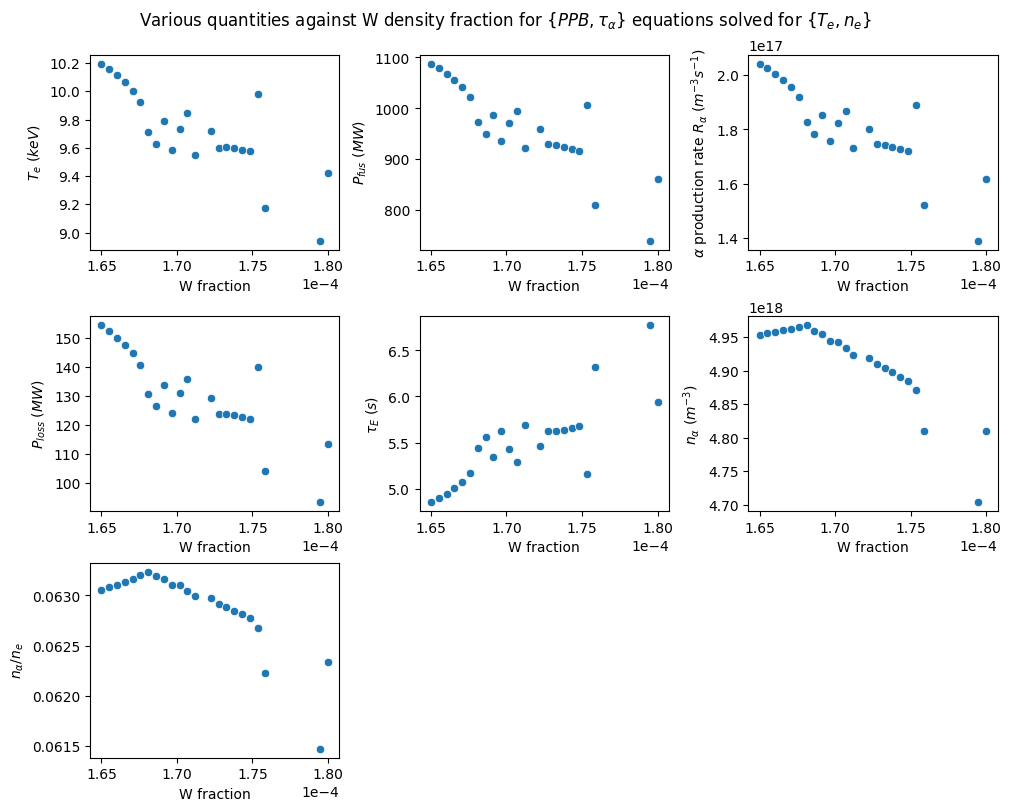

In [53]:
# Plot
sol_df = pd.DataFrame(sol_data)
fig, ax = plt.subplots(ncols=3, nrows=3, layout="constrained")
fig.set_size_inches(10, 8)

# te plot
ax0 = sns.scatterplot(
    data=sol_df,
    x="w",
    y="te",
    ax=ax[0, 0],
)
ax0.set_xlabel("W fraction")
ax0.set_ylabel(r"$T_e$ $(keV)$")
ax0.ticklabel_format(style="sci", axis="x", scilimits=(0, 0))

# pfus plot
ax1 = sns.scatterplot(
    data=sol_df,
    x="w",
    y="pfus",
    ax=ax[0, 1],
)
ax1.set_xlabel("W fraction")
ax1.set_ylabel(r"$P_{fus}$ $(MW)$")
ax1.ticklabel_format(style="sci", axis="x", scilimits=(0, 0))

# alpha plot
ax2 = sns.scatterplot(
    data=sol_df,
    x="w",
    y="he",
    ax=ax[0, 2],
)
ax2.set_xlabel("W fraction")
ax2.set_ylabel(r"$\alpha$ production rate $R_{\alpha}$ $(m^{-3}s^{-1})$")
ax2.ticklabel_format(style="sci", axis="x", scilimits=(0, 0))

# ploss plot
ax3 = sns.scatterplot(
    data=sol_df,
    x="w",
    y="ploss",
    ax=ax[1, 0],
)
ax3.set_xlabel("W fraction")
ax3.set_ylabel(r"$P_{loss}$ $(MW)$")
ax3.ticklabel_format(style="sci", axis="x", scilimits=(0, 0))

# tau_E plot
ax4 = sns.scatterplot(
    data=sol_df,
    x="w",
    y="tau_e_scaling_hfact",
    ax=ax[1, 1],
)
ax4.set_xlabel("W fraction")
ax4.set_ylabel(r"$\tau_E$ $(s)$")
ax4.ticklabel_format(style="sci", axis="x", scilimits=(0, 0))

# nd_alphas plot
ax5 = sns.scatterplot(
    data=sol_df,
    x="w",
    y="nd_alphas",
    ax=ax[1, 2],
)
ax5.set_xlabel("W fraction")
ax5.set_ylabel(r"$n_{\alpha}$ $(m^{-3})$")
ax5.ticklabel_format(style="sci", axis="x", scilimits=(0, 0))

# f_nd_alpha_electron plot
ax6 = sns.scatterplot(
    data=sol_df,
    x="w",
    y="f_nd_alpha_electron",
    ax=ax[2, 0],
)
ax6.set_xlabel("W fraction")
ax6.set_ylabel(r"$n_{\alpha}/n_{e}$")
ax6.ticklabel_format(style="sci", axis="x", scilimits=(0, 0))

ax[2, 1].axis("off")
ax[2, 2].axis("off")

fig.suptitle(
    r"Various quantities against W density fraction for $\{PPB, \tau_\alpha\}$ equations solved for $\{T_e, n_e\}$"
)

n_alpha / n_E turns over when the fusion produced alphas reduce significantly: the reduction in n_alpha dominates the increase in tau_E. Clearly there's some bad behaviour going on, which can be investigated if needed.

Focus on one plot only:

In [2]:
w_fracs = np.linspace(1.60e-4, 1.8e-4, 30)
# w_fracs = np.array([1.9e-4])  # 1.9e-4 fails
sol_data = {
    "w": [],
    "tau_e_scaling_hfact": [],
    "te": [],
    "ne": [],
    "pfus": [],
    "he": [],
    "ploss": [],
    "nd_alphas": [],
    "f_nd_alpha_electron": [],
}
for w_frac in w_fracs:
    # Solve Process each time after modifying W fraction
    single_run = SingleRun("lt_tau_alpha_sol_IN.DAT")
    process.fortran.impurity_radiation_module.impurity_arr_frac[13] = w_frac
    try:
        # Handle failed runs
        single_run.run()
    except Exception:
        continue
    sol_data["w"].append(w_frac)
    sol_data["tau_e_scaling_hfact"].append(
        process.fortran.physics_variables.t_energy_confinement.item()
    )
    sol_data["te"].append(process.fortran.physics_variables.te.item())
    sol_data["ne"].append(process.fortran.physics_variables.dene.item())
    sol_data["pfus"].append(process.fortran.physics_variables.p_fusion_total_mw.item())
    sol_data["he"].append(process.fortran.physics_variables.fusden_plasma_alpha.item())
    sol_data["ploss"].append(process.fortran.physics_variables.p_plasma_loss_mw.item())
    sol_data["nd_alphas"].append(process.fortran.physics_variables.nd_alphas.item())
    sol_data["f_nd_alpha_electron"].append(
        process.fortran.physics_variables.f_nd_alpha_electron.item()
    )

# Clear the lengthy stdout from multiple process runs
clear_output()

Text(0.5, 0.98, '$T_e$ and $n_\\alpha/n_e$ against high W density fractions for $\\{PPB, \\tau_\\alpha\\}$ equations solved for $\\{T_e, n_e\\}$')

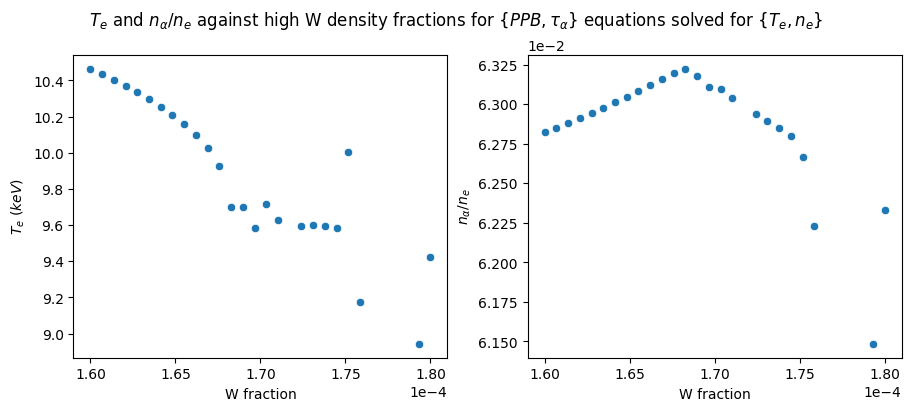

In [13]:
# Plot
sol_df = pd.DataFrame(sol_data)
fig, ax = plt.subplots(ncols=2, layout="constrained")
fig.set_size_inches(9, 4)

# te plot
ax0 = sns.scatterplot(
    data=sol_df,
    x="w",
    y="te",
    ax=ax[0],
)
ax0.set_xlabel("W fraction")
ax0.set_ylabel(r"$T_e$ $(keV)$")
ax0.ticklabel_format(style="sci", axis="x", scilimits=(0, 0))

# f_nd_alpha_electron plot
ax6 = sns.scatterplot(
    data=sol_df,
    x="w",
    y="f_nd_alpha_electron",
    ax=ax[1],
)
ax6.set_xlabel("W fraction")
ax6.set_ylabel(r"$n_{\alpha}/n_{e}$")
ax6.ticklabel_format(style="sci", axis="x", scilimits=(0, 0))
ax6.ticklabel_format(style="sci", axis="y", scilimits=(0, 0))

fig.suptitle(
    r"$T_e$ and $n_\alpha/n_e$ against high W density fractions for $\{PPB, \tau_\alpha\}$ equations solved for $\{T_e, n_e\}$"
)